#Analyse exploratoire des ventes d'une Chaine de vente d'electroniques
Les sources des données de ventes d'une entreprise sur l'année 2019. Donc un fichier csv par mois.

Chaque fichier contient les colonnes suivantes:

*  OrderID: l'identifiant unique de la commande
*  Product: La désignation du produit
*  Quantity Ordered: la quantité vendue
*  Price each: le prix unitaire
*  order date : La date d'achat
*  Purchase adress: l'adresse de la boutique de vente

Nous allons analyser ces données pour répondre aux questions suivantes:

*  Quel est le meilleur mois de vente ? et Quel est le chiffre d'affaires de ce mois ?
*  Dans quelle ville a-t-on le plus vendu de produits ?
*  A quelle heure devons-nous passer de la publicité pour augmenter nos ventes ?
*  Quels sont les produits qui sont souvent achetés ensemble ?
*  Quel produit a-t-on le plus vendu et pourquoi ?


In [1]:
#Importation des bibliothèques pour l'analyse de données
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#Importer les données

In [3]:
#Liste des mois de l'année
mois=["January", "February", "March", "April", "May", "June", "July", "August",
                  "September", "October", "November", "December"]

In [4]:
#Génération des liens des fichiers de ventes par mois
files=[f"https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_{month}_2019.csv" for month in mois]

In [5]:
files

['https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_January_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_February_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_March_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_April_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_May_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_June_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/refs/heads/main/datasets/SalesAnalysis/Sales_Data/Sales_July_2019.csv',
 'https://raw.githubusercontent.com/kevindegila/data-analyst/

In [6]:
#Fusionons les fichiers de ventes en un seul DataFrame
df = pd.DataFrame()

for lien in files:
  data_interm = pd.read_csv(lien)
  df = pd.concat([df, data_interm])

In [ ]:
#Dimensions du DataFrame
df.shape

(186850, 6)

Nous avons 186850 lignes et 6 colonnes

In [ ]:
#Affichage des informations du DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186850 entries, 0 to 25116
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 10.0+ MB


On constate que les colonnes contiennent des valeurs nulles et tous les types de données sont object.

#Nettoyage de la data

In [ ]:
#Verification de la valeur manquante
df.isnull().sum(axis=0)

,0
Order ID,545
Product,545
Quantity Ordered,545
Price Each,545
Order Date,545
Purchase Address,545


In [ ]:
#Affichons un df avec toutes les lignes qui ont au moins une valeur manquante
val_manquantes = df[df.isnull().any(axis=1)]
val_manquantes

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
664,NaN,NaN,NaN,NaN,NaN,NaN
678,NaN,NaN,NaN,NaN,NaN,NaN
797,NaN,NaN,NaN,NaN,NaN,NaN
876,NaN,NaN,NaN,NaN,NaN,NaN
1299,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
22945,NaN,NaN,NaN,NaN,NaN,NaN
22962,NaN,NaN,NaN,NaN,NaN,NaN
23309,NaN,NaN,NaN,NaN,NaN,NaN
23996,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Est-ce que toutes les lignes n'ont que des valeurs manquantes
val_manquantes.isnull().all()

,0
Order ID,True
Product,True
Quantity Ordered,True
Price Each,True
Order Date,True
Purchase Address,True


In [ ]:
df.shape

(186850, 6)

In [ ]:
#Supprimer toutes les lignes avec des valeurs manquantes:
df.dropna(inplace=True)

In [ ]:
df.shape

(186305, 6)

Après suppression ns avons 186305 lignes et 6 colonnes

In [ ]:
#Verifions si ya un true de dans data frame def aprés la suppresion des valeurs manquantes
df.isnull().any()

,0
Order ID,False
Product,False
Quantity Ordered,False
Price Each,False
Order Date,False
Purchase Address,False


In [ ]:
# Affichage des statistiques descriptives
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


In [ ]:
#Débarassons-nous des lignes avec des valeurs abérantes
df[df['Order Date'] == "Order Date"]


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1073,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1102,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1194,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1897,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2463,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
23198,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23337,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23748,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
24192,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [ ]:
#Sélection des lignes avec un "Order ID" non numérique
df.loc[~df['Order ID'].str.isdigit(), : ]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1073,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1102,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1194,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1897,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2463,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
23198,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23337,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
23748,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
24192,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [ ]:
#Suppression des lignes avec 'Order Date' invalide
df_clean = df.drop(df.loc[df['Order Date'] == "Order Date", :].index)

In [ ]:
#Recherche des lignes non valides dans 'Order ID' après nettoyage
df_clean.loc[~df_clean['Order ID'].str.isdigit(), : ]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


On na constater que y'a aucune ligne non valide dans le data frame

In [ ]:
#Changement des Types de données
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"


Changement des Types de données pour les colonnes : 'Quantity Ordered' en int, 'Price Each' en float et 'Order Date' en datetime

In [ ]:
#Conversion de 'Quantity Ordered' en entier
df_clean['Quantity Ordered'] = df_clean['Quantity Ordered'].astype('int')

In [ ]:
#Conversion de 'Price Each' en numérique
df_clean['Price Each'] = pd.to_numeric(df_clean['Price Each'])

In [ ]:
#Conversion de 'Order Date' en datetime
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])

<ipython-input-54-8bd24490f977>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])


In [ ]:
#Affichage des informations du DataFrame à nouveau
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182735 entries, 0 to 25116
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          182735 non-null  object        
 1   Product           182735 non-null  object        
 2   Quantity Ordered  182735 non-null  int64         
 3   Price Each        182735 non-null  float64       
 4   Order Date        182735 non-null  datetime64[ns]
 5   Purchase Address  182735 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 9.8+ MB


In [ ]:
#Affichage de la colonne 'Order Date'
df['Order Date']

,Order Date
0,01/22/19 21:25
1,01/28/19 14:15
2,01/17/19 13:33
3,01/05/19 20:33
4,01/25/19 11:59
...,...
25112,12/11/19 20:58
25113,12/01/19 12:01
25114,12/09/19 06:43
25115,12/03/19 10:39


In [ ]:
#Affichage de la colonne 'Order Date' après changement de type de données
df_clean['Order Date']

,Order Date
0,2019-01-22 21:25:00
1,2019-01-28 14:15:00
2,2019-01-17 13:33:00
3,2019-01-05 20:33:00
4,2019-01-25 11:59:00
...,...
25112,2019-12-11 20:58:00
25113,2019-12-01 12:01:00
25114,2019-12-09 06:43:00
25115,2019-12-03 10:39:00


#Analyse Exploratoire proprement dite

Quel est le meilleur mois de vente ? et Quel est le chiffre d'affaires de ce mois ?

In [ ]:
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700.00,2019-01-22 21:25:00,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,2019-01-28 14:15:00,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,2019-01-17 13:33:00,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,2019-01-05 20:33:00,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,2019-01-25 11:59:00,"387 10th St, Austin, TX 73301"


In [ ]:
#Affichage des index du DataFrame nettoyé
df_clean.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       25107, 25108, 25109, 25110, 25111, 25112, 25113, 25114, 25115, 25116],
      dtype='int64', length=182735)

In [ ]:
#Définition de 'Order Date' comme index du DataFrame
df_clean  = df_clean.set_index('Order Date')

In [ ]:
#Affichons les 5 premières lignes du DataFrame
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-22 21:25:00,141234,iPhone,1,700.00,"944 Walnut St, Boston, MA 02215"
2019-01-28 14:15:00,141235,Lightning Charging Cable,1,14.95,"185 Maple St, Portland, OR 97035"
2019-01-17 13:33:00,141236,Wired Headphones,2,11.99,"538 Adams St, San Francisco, CA 94016"
2019-01-05 20:33:00,141237,27in FHD Monitor,1,149.99,"738 10th St, Los Angeles, CA 90001"
2019-01-25 11:59:00,141238,Wired Headphones,1,11.99,"387 10th St, Austin, TX 73301"


In [ ]:
#Trions la colonne "Order Date" par ordre croissant
df_clean.sort_index(inplace=True)

In [ ]:
#Affichons les 5 premières lignes du DataFrame
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address
Order Date,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001"
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016"
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001"
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001"
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301"


In [ ]:
#Créons la colonne mois en lettre
df_clean['Month'] = df_clean.index.month_name()

In [ ]:
#Affichons les 5 premières lignes du DataFrame
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month
Order Date,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January


In [ ]:
# Calcul du chiffre d'affaires
df_clean['chiffre_daffaire'] = df_clean['Quantity Ordered'] * df_clean['Price Each']

In [ ]:
#Affichage d’un échantillon de 5 lignes aléatoires
df_clean.sample(5)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,chiffre_daffaire
Order Date,,,,,,,
2019-03-21 15:53:00,167451,Wired Headphones,1,11.99,"306 1st St, San Francisco, CA 94016",March,11.99
2019-12-16 20:31:00,317228,USB-C Charging Cable,1,11.95,"91 Willow St, Seattle, WA 98101",December,11.95
2019-02-28 10:40:00,153512,AAA Batteries (4-pack),2,2.99,"483 Maple St, Boston, MA 02215",February,5.98
2019-05-07 11:36:00,208645,27in FHD Monitor,1,149.99,"466 Jackson St, New York City, NY 10001",May,149.99
2019-10-28 13:59:00,265255,AA Batteries (4-pack),1,3.84,"759 5th St, New York City, NY 10001",October,3.84


In [ ]:
#Chiffre d'affaires total par mois (trié par ordre décroissant)
df_clean.groupby('Month')["chiffre_daffaire"].sum().sort_values(ascending=False)

,chiffre_daffaire
Month,
December,4557905.42
October,3679254.16
April,3336376.42
November,3149785.09
May,3101881.04
March,2755969.40
July,2587444.91
June,2524464.99
August,2191698.31


In [ ]:
#Liste des mois de l'année
order = ["January", "February", "March", "April", "May", "June", "July", "August",
                  "September", "October", "November", "December"]

In [ ]:
#Chiffre d'affaires total par mois selon l'ordre défini
df_clean.groupby('Month')["chiffre_daffaire"].sum().loc[order]

,chiffre_daffaire
Month,
January,1786511.29
February,2158127.48
March,2755969.40
April,3336376.42
May,3101881.04
June,2524464.99
July,2587444.91
August,2191698.31
September,2050361.26


Text(0.5, 1.0, "Chiffre d'affaire global par mois")

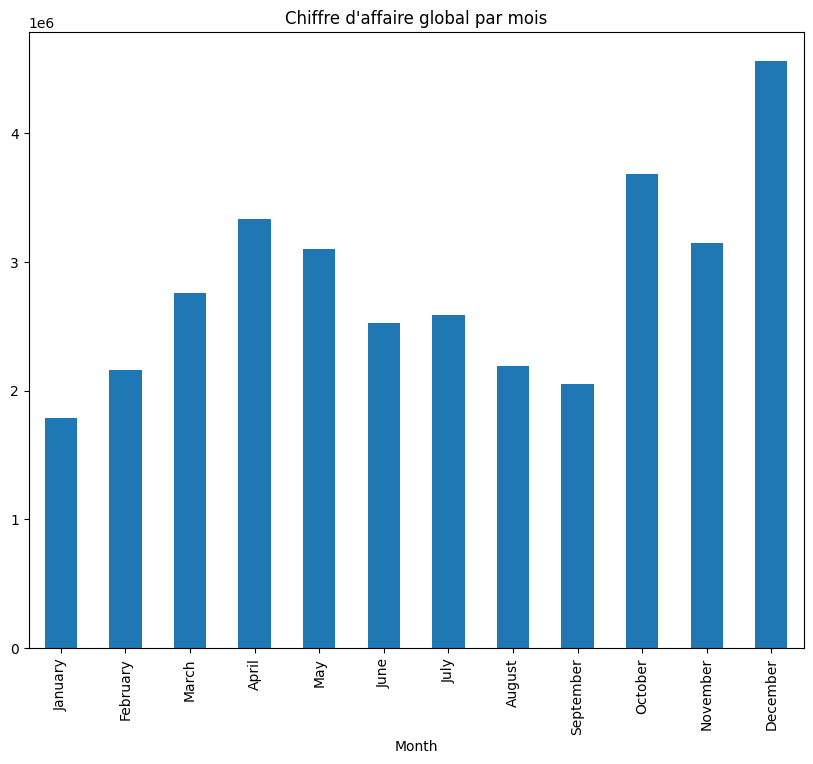

In [ ]:
df_clean.groupby('Month')["chiffre_daffaire"].sum().loc[order].plot.bar(figsize=(10, 8))
plt.title("Chiffre d'affaire global par mois")

In [ ]:
#Chiffre d'affaires de décembre (après tri décroissant par mois)
df_clean.groupby('Month').sum()["chiffre_daffaire"].sort_values(ascending=False).December

np.float64(4557905.42)

Décembre est le mois avec le plus de ventes et le CA est de 4557905.420001525

Dans quelle ville a-t-on le plus vendu de produits ?

In [ ]:
#Liste des adresses d'achat uniques
df_clean['Purchase Address'].unique()


array(['9 Lake St, New York City, NY 10001',
       '760 Church St, San Francisco, CA 94016',
       '735 5th St, New York City, NY 10001', ...,
       '731 7th St, New York City, NY 10001',
       '754 Hickory St, New York City, NY 10001',
       '657 Spruce St, New York City, NY 10001'], dtype=object)

In [ ]:
# Recuperons une ville

In [ ]:
# Récupérons une ville
def get_ville(addresse):
  return addresse.split(',')[1].strip()


In [ ]:
get_ville("760 Church St, San Francisco, CA 94016")

'San Francisco'

In [ ]:
#Appliquons pour toutes les villes et créons la colonne ville
df_clean['ville'] = df_clean['Purchase Address'].apply(get_ville)

In [ ]:
# Affichage d’un échantillon de 5 lignes aléatoires
df_clean.sample(5)

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,chiffre_daffaire,ville
Order Date,,,,,,,,
2019-07-03 16:37:00,230355,AA Batteries (4-pack),2,3.84,"849 Maple St, Boston, MA 02215",July,7.68,Boston
2019-07-22 14:46:00,227175,iPhone,1,700.00,"382 River St, Dallas, TX 75001",July,700.00,Dallas
2019-11-08 20:09:00,288230,Wired Headphones,1,11.99,"875 Jefferson St, San Francisco, CA 94016",November,11.99,San Francisco
2019-05-20 23:38:00,201070,27in 4K Gaming Monitor,1,389.99,"879 North St, Portland, OR 97035",May,389.99,Portland
2019-05-21 13:49:00,197540,34in Ultrawide Monitor,1,379.99,"383 Madison St, Austin, TX 73301",May,379.99,Austin


In [ ]:
#Liste des villes uniques
df_clean['ville'].unique()

array(['New York City', 'San Francisco', 'Dallas', 'Atlanta', 'Boston',
       'Seattle', 'Los Angeles', 'Portland', 'Austin'], dtype=object)

In [ ]:
#chiffre_daffaire par ville
df_clean.groupby('ville').sum()["chiffre_daffaire"].sort_values(ascending=False)

,chiffre_daffaire
ville,
San Francisco,8124120.94
Los Angeles,5354039.93
New York City,4581658.91
Boston,3604080.86
Atlanta,2741642.05
Dallas,2717793.72
Seattle,2693048.60
Portland,2276649.24
Austin,1786745.52


<Axes: ylabel='ville'>

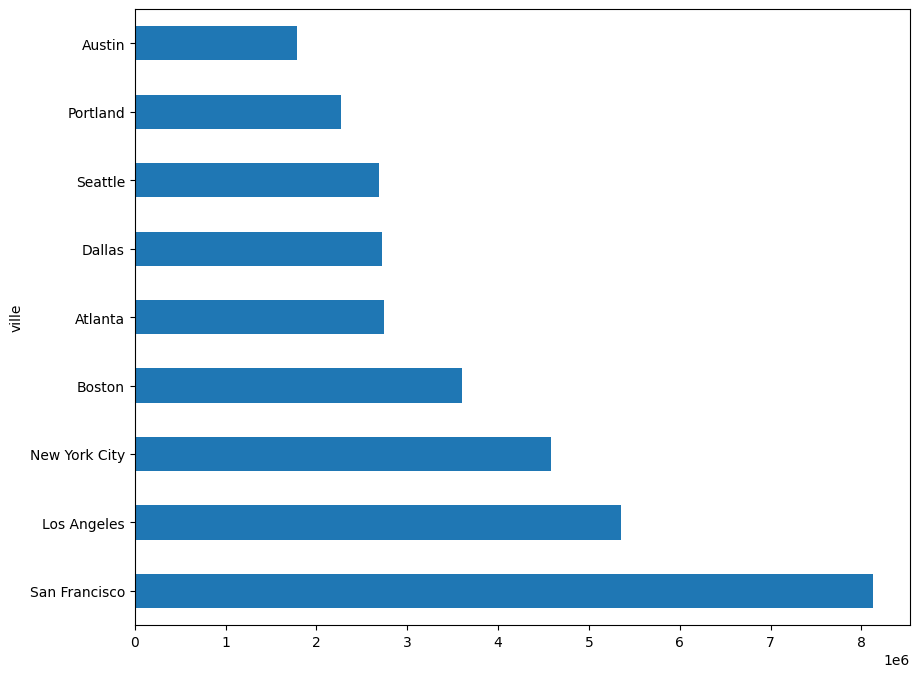

In [ ]:
df_clean.groupby('ville').sum()["chiffre_daffaire"].sort_values(ascending=False).plot.barh(figsize=(10, 8))

On a fait un meilleur chiffre d'affaire à San Francisco

In [ ]:
ca_by_ville = df_clean.groupby('ville').sum()["chiffre_daffaire"].sort_values(ascending=False)

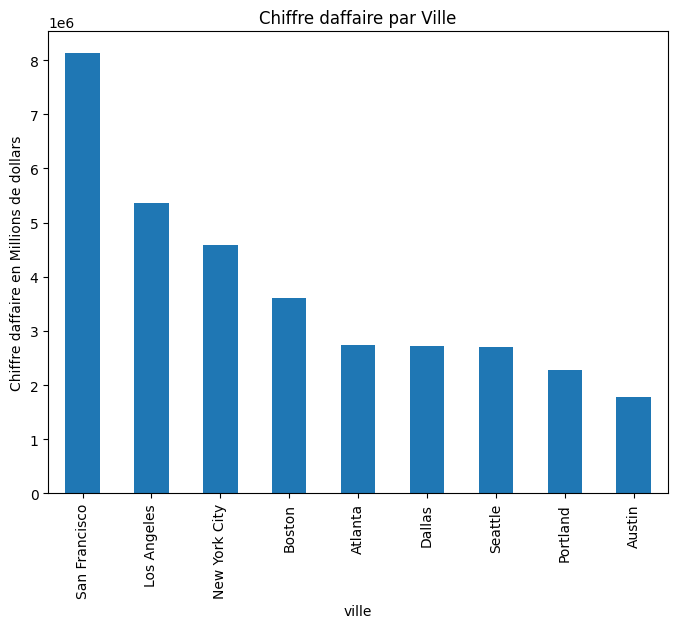

In [ ]:
ca_by_ville.plot(kind='bar', figsize=(8, 6))
plt.ylabel('Chiffre daffaire en Millions de dollars')
plt.title('Chiffre daffaire par Ville')
plt.show()

On a fait un meilleur chiffre d'affaire à San Francisco

A quelle heure devons-nous passer de la publicité pour augmenter nos ventes ?

A quelle heure on vend le plus ?

In [ ]:
#Créons les colonnes "heure" et "time" ?
df_clean['heure'] = df_clean.index.hour
df_clean['time'] = df_clean.index.time

In [ ]:
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,chiffre_daffaire,ville,heure,time
Order Date,,,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,11.99,New York City,3,03:07:00
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,11.95,San Francisco,3,03:40:00
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,150.00,New York City,4,04:56:00
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,2.99,Dallas,5,05:53:00
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,23.90,Atlanta,6,06:03:00


In [ ]:
#Calcul du chiffre d'affaires par heure
ca_par_heure = pd.DataFrame(df_clean.groupby('heure')['chiffre_daffaire'].sum())

In [ ]:
ca_par_heure

,chiffre_daffaire
heure,
0,698694.76
1,447663.86
2,234191.08
3,142976.54
4,161350.57
5,224313.72
6,441523.14
7,734595.75
8,1181363.76


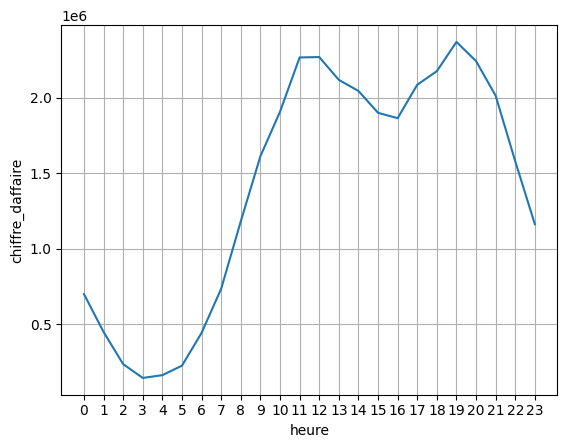

In [ ]:
sns.lineplot(data=ca_par_heure['chiffre_daffaire'])
plt.xticks(ticks=range(0, 24))
plt.grid()
plt.show()

On devrait afficher la publicité entre 10 et 11 et entre 18 et 19.





Quels sont les produits qui sont souvent achetés ensemble ?

In [ ]:
#Les produits vendus ensemble ont le même Order ID.
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,chiffre_daffaire,ville,heure,time
Order Date,,,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,11.99,New York City,3,03:07:00
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,11.95,San Francisco,3,03:40:00
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,150.00,New York City,4,04:56:00
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,2.99,Dallas,5,05:53:00
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,23.90,Atlanta,6,06:03:00


Les ventes avec plus d'un produit :

In [ ]:
df_m = df_clean[df_clean['Order ID'].duplicated(keep=False)].copy()
df_m

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,chiffre_daffaire,ville,heure,time
Order Date,,,,,,,,,,
2019-01-01 07:29:00,144804,Wired Headphones,1,11.99,"628 Lake St, New York City, NY 10001",January,11.99,New York City,7,07:29:00
2019-01-01 07:29:00,144804,iPhone,1,700.00,"628 Lake St, New York City, NY 10001",January,700.00,New York City,7,07:29:00
2019-01-01 11:25:00,148074,Google Phone,1,600.00,"6 Johnson St, Atlanta, GA 30301",January,600.00,Atlanta,11,11:25:00
2019-01-01 11:25:00,148074,USB-C Charging Cable,1,11.95,"6 Johnson St, Atlanta, GA 30301",January,11.95,Atlanta,11,11:25:00
2019-01-01 12:02:00,148450,iPhone,1,700.00,"761 Lakeview St, Dallas, TX 75001",January,700.00,Dallas,12,12:02:00
...,...,...,...,...,...,...,...,...,...,...
2020-01-01 00:10:00,311386,Apple Airpods Headphones,1,150.00,"730 Pine St, San Francisco, CA 94016",January,150.00,San Francisco,0,00:10:00
2020-01-01 00:22:00,297817,Lightning Charging Cable,2,14.95,"519 13th St, New York City, NY 10001",January,29.90,New York City,0,00:22:00
2020-01-01 00:22:00,297817,iPhone,1,700.00,"519 13th St, New York City, NY 10001",January,700.00,New York City,0,00:22:00


In [ ]:
#Fonction pour concaténer les produits par 'Order ID'
def concat_produit_par_order_id(p: list):
  return ";".join(p)

In [ ]:
#Concaténation des produits par 'Order ID'
df_m.groupby('Order ID')['Product'].apply(concat_produit_par_order_id)

,Product
Order ID,
141275,USB-C Charging Cable;Wired Headphones
141290,Apple Airpods Headphones;AA Batteries (4-pack)
141365,Wired Headphones;Vareebadd Phone
141384,USB-C Charging Cable;Google Phone
141450,Bose SoundSport Headphones;Google Phone
...,...
319536,Wired Headphones;Macbook Pro Laptop
319556,Google Phone;Wired Headphones
319584,iPhone;Wired Headphones


In [ ]:
ensemble = df_m.groupby('Order ID')['Product'].apply(concat_produit_par_order_id)

In [ ]:
#Importation des modules pour combinaisons et comptage
from itertools import combinations
from collections import Counter

count = Counter()

In [ ]:
#Conversion de l'ensemble en liste
ensemble.to_list()

['USB-C Charging Cable;Wired Headphones',
 'Apple Airpods Headphones;AA Batteries (4-pack)',
 'Wired Headphones;Vareebadd Phone',
 'USB-C Charging Cable;Google Phone',
 'Bose SoundSport Headphones;Google Phone',
 'Apple Airpods Headphones;iPhone',
 'Google Phone;Apple Airpods Headphones',
 'iPhone;Apple Airpods Headphones;Wired Headphones',
 'Apple Airpods Headphones;USB-C Charging Cable',
 'Wired Headphones;Lightning Charging Cable',
 'iPhone;Lightning Charging Cable',
 '27in FHD Monitor;Bose SoundSport Headphones',
 'USB-C Charging Cable;Google Phone',
 'Wired Headphones;iPhone',
 'Google Phone;USB-C Charging Cable',
 'AA Batteries (4-pack);AAA Batteries (4-pack)',
 'Vareebadd Phone;Wired Headphones;USB-C Charging Cable',
 'USB-C Charging Cable;Google Phone',
 'Vareebadd Phone;Wired Headphones',
 'Lightning Charging Cable;34in Ultrawide Monitor',
 'USB-C Charging Cable;Wired Headphones',
 'Lightning Charging Cable;Bose SoundSport Headphones',
 'Wired Headphones;Google Phone',
 'Wired

In [ ]:
#Comptage des combinaisons de produits par achat
for achat in ensemble.to_list():
    products = achat.split(';')
#     print(products)
    count.update(Counter(combinations(products, 2)))

In [ ]:
count

Counter({('USB-C Charging Cable', 'Wired Headphones'): 101,
         ('Apple Airpods Headphones', 'AA Batteries (4-pack)'): 37,
         ('Wired Headphones', 'Vareebadd Phone'): 82,
         ('USB-C Charging Cable', 'Google Phone'): 474,
         ('Bose SoundSport Headphones', 'Google Phone'): 115,
         ('Apple Airpods Headphones', 'iPhone'): 159,
         ('Google Phone', 'Apple Airpods Headphones'): 11,
         ('iPhone', 'Apple Airpods Headphones'): 196,
         ('iPhone', 'Wired Headphones'): 236,
         ('Apple Airpods Headphones', 'Wired Headphones'): 48,
         ('Apple Airpods Headphones', 'USB-C Charging Cable'): 24,
         ('Wired Headphones', 'Lightning Charging Cable'): 70,
         ('iPhone', 'Lightning Charging Cable'): 509,
         ('27in FHD Monitor', 'Bose SoundSport Headphones'): 13,
         ('Wired Headphones', 'iPhone'): 216,
         ('Google Phone', 'USB-C Charging Cable'): 492,
         ('AA Batteries (4-pack)', 'AAA Batteries (4-pack)'): 45,
       

In [ ]:
 #Affichage de la combinaison de produits la plus fréquente
count.most_common(1)

[(('iPhone', 'Lightning Charging Cable'), 509)]

In [ ]:
[(('USB-C Charging Cable', 'Google Phone'), 498)]

[(('USB-C Charging Cable', 'Google Phone'), 498)]

In [ ]:
#Affichage des 10 combinaisons de produits les plus fréquentes
for ensemble, c in count.most_common(10):
    print(ensemble, c)

('iPhone', 'Lightning Charging Cable') 509
('Google Phone', 'USB-C Charging Cable') 492
('USB-C Charging Cable', 'Google Phone') 474
('Lightning Charging Cable', 'iPhone') 474
('iPhone', 'Wired Headphones') 236
('Wired Headphones', 'iPhone') 216
('Wired Headphones', 'Google Phone') 215
('iPhone', 'Apple Airpods Headphones') 196
('Google Phone', 'Wired Headphones') 195
('Vareebadd Phone', 'USB-C Charging Cable') 188


Produit le plus vendu

In [ ]:
df_clean.head()

,Order ID,Product,Quantity Ordered,Price Each,Purchase Address,Month,chiffre_daffaire,ville,heure,time
Order Date,,,,,,,,,,
2019-01-01 03:07:00,147268,Wired Headphones,1,11.99,"9 Lake St, New York City, NY 10001",January,11.99,New York City,3,03:07:00
2019-01-01 03:40:00,148041,USB-C Charging Cable,1,11.95,"760 Church St, San Francisco, CA 94016",January,11.95,San Francisco,3,03:40:00
2019-01-01 04:56:00,149343,Apple Airpods Headphones,1,150.00,"735 5th St, New York City, NY 10001",January,150.00,New York City,4,04:56:00
2019-01-01 05:53:00,149964,AAA Batteries (4-pack),1,2.99,"75 Jackson St, Dallas, TX 75001",January,2.99,Dallas,5,05:53:00
2019-01-01 06:03:00,149350,USB-C Charging Cable,2,11.95,"943 2nd St, Atlanta, GA 30301",January,23.90,Atlanta,6,06:03:00


In [ ]:
#Total des quantités commandées par produit (tri décroissant)
df_clean.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

,Quantity Ordered
Product,
AAA Batteries (4-pack),30487
AA Batteries (4-pack),27148
USB-C Charging Cable,23555
Lightning Charging Cable,22841
Wired Headphones,20201
Apple Airpods Headphones,15383
Bose SoundSport Headphones,13236
27in FHD Monitor,7429
iPhone,6732
